# Task 5: Capstone, redesign one chart for the human visual system
Data: `diamonds.csv`, 53,940 rows, 0 missing values. Every chart is built with `fig, ax = plt.subplots()`.

**Honest note:** the human test needs a real person and I cannot be one. The cell for it is ready, but the reader's sentence is **not** filled in; I have not invented one.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

d = pd.read_csv('diamonds.csv')
OC = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']          # cut is ORDERED, worst to best
d['cut'] = pd.Categorical(d.cut, categories=OC, ordered=True)
assert len(d) == 53940 and d.isna().sum().sum() == 0              # no missing values anywhere
GREY, HI = '#9a9a9a', '#cc3311'
usd = FuncFormatter(lambda v, _: f'${v:,.0f}')

## 1. The bad chart
**BAD EXAMPLE:** all 53,940 diamonds plotted raw (price vs carat), coloured by cut with a rainbow, in file order, with heavy gridlines and a frame.
**The one question a reader should be able to answer from it:** *do better-cut diamonds cost more?*

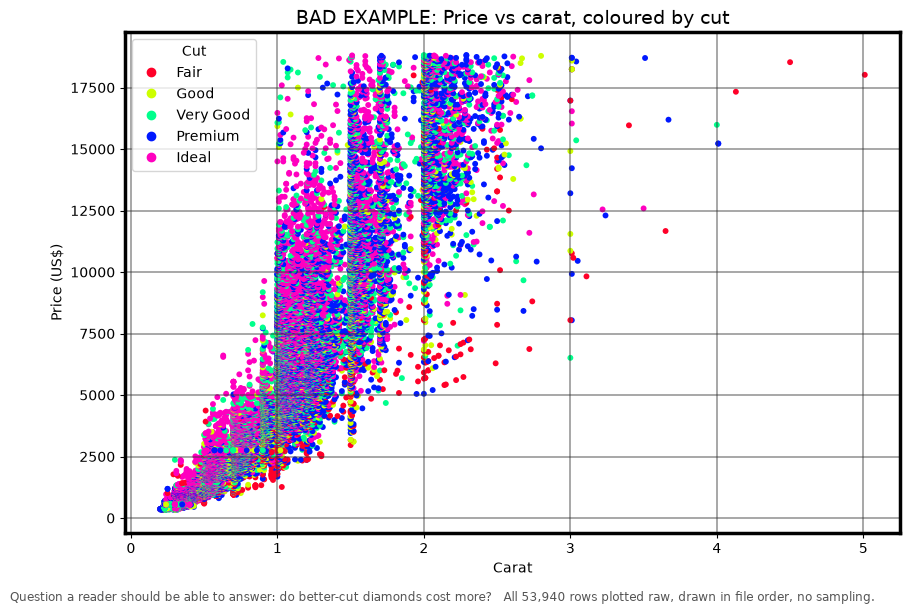

               n  median_price  mean_carat
cut                                       
Fair        1610        3282.0        1.05
Good        4906        3050.5        0.85
Very Good  12082        2648.0        0.81
Premium    13791        3185.0        0.89
Ideal      21551        1810.0        0.70


In [2]:
fig, ax = plt.subplots(figsize=(10, 6.5))
sc = ax.scatter(d.carat, d.price, c=d.cut.cat.codes, cmap='gist_rainbow', s=18, linewidths=0)   # all 53,940 rows, raw, file order
ax.legend(handles=[Line2D([], [], marker='o', ls='', color=sc.cmap(sc.norm(i)), label=c) for i, c in enumerate(OC)],
          title='Cut', loc='upper left')
ax.grid(True, color='#333333', lw=1.2, alpha=0.5)
for s in ax.spines.values(): s.set_linewidth(2.5)
ax.set_xlabel('Carat'); ax.set_ylabel('Price (US$)')
ax.set_title('BAD EXAMPLE: Price vs carat, coloured by cut', fontsize=14)
fig.text(0.01, 0.005, 'Question a reader should be able to answer: do better-cut diamonds cost more?   '
         'All 53,940 rows plotted raw, drawn in file order, no sampling.', fontsize=8.5, color='#555')
fig.savefig('t5_bad_example.png', dpi=130, bbox_inches='tight'); plt.show()
print(d.groupby('cut', observed=True).agg(n=('price', 'size'), median_price=('price', 'median'), mean_carat=('carat', 'mean')).round(2))

## 2. Perception audit of the BAD chart (before fixing anything)

| Row | Audit of the bad chart |
|---|---|
| **Preattentive** | In play: **position** (x = carat, y = price) and **hue** (5 saturated colours for cut). Position does useful work: the upward fan shows price rising with carat. Hue does none: cut is *ordered*, hue has no order, and five hues interleaved over 54k points cannot be separated. |
| **Pop-out** | What pops out is arbitrary: whichever colour was drawn last in each region (file order), plus bright high-price outliers. None of it answers "do better cuts cost more?", so the pop-out does **not** match the question. |
| **Gestalt** | Similarity (same hue = same cut) is triggered but cannot group, because the hues overlap in space. Proximity groups the points by *carat* (vertical stripes at round weights such as 0.5 and 1.0), so it groups the **wrong thing**. |
| **Cognitive load** | **Intrinsic:** the 53,940 (carat, price) positions, axis scales and units. **Extraneous:** rainbow hue per cut, 5-entry legend (colour → key → dot matching), heavy gridlines in both directions, 2.5 pt frame, severe overplotting. **Germane:** none; nothing is summarised, sorted or highlighted. |
| **Channels** | Price → y position (rank 1 for quantities: good). Carat → x position (rank 1: good). Cut (ordinal) → hue, a channel for *nominal* data with no order: poor; position or a lightness ramp would suit ordered data. |
| **Working memory** | 5 colour-to-cut pairs from the legend + 2 axes + an unchunkable 54k-point cloud: well over 4 ± 1 chunks. |

## 3. The rebuild: one figure, one message
**Message:** at the same weight, Ideal-cut diamonds cost about 40% more than Fair-cut ones.

The raw data hides this: ignoring weight, Ideal has the *lowest* median price ($1,810) and Fair one of the highest ($3,282), because Ideal diamonds are smaller on average (0.70 vs 1.05 carat). So the redesign **holds weight roughly constant** (0.90 to 1.10 carat) and compares cuts inside that band.

Design decisions, each tied to this week:
- **One pop-out:** one red median line with its two end labels, carrying the title's message. Hue is used only as a "this is the message" flag, never as data.
- **Grey is a colour choice:** the 750 sampled diamonds are context, in grey with transparency.
- **Gestalt principle doing the grouping: proximity.** Dots of the same cut sit together in one column, so the eye sees five groups without a legend. (The line's continuity helps read the trend between columns; it is not what groups.)
- **Highest-ranking channel for the most important variable:** price, the thing being compared, goes on **y position along a common scale** with a zero baseline. Cut (ordered) is on **x position**, in order, with text labels. Carat is held fixed by the filter rather than encoded.
- **No information by colour alone:** cut is carried by position and text labels; the red line is also labelled directly with the two medians.
- **Chunking (4 ± 1):** grey cloud, rising line, "Fair" label, "Ideal" label. The five cut names read as one ordered sequence.
- **Sampling and exclusions are declared on the figure:** 150 dots per cut (seed 5) of the 10,331 in the band; medians use all 10,331; 43,609 rows outside the band excluded; 0 missing values.
- **Ink removed and why:** legend (cut is on the x axis), frame and heavy gridlines (carried no number), the rainbow (encoded nothing position doesn't), 43,609 off-band points (not relevant to this question).

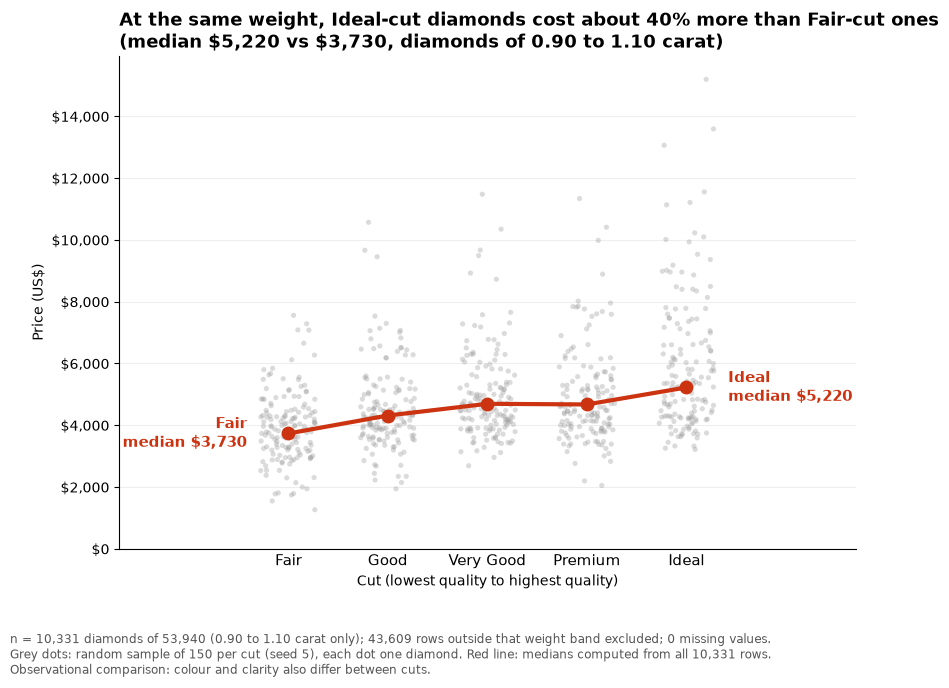

{'Fair': 3730.0, 'Good': 4312.0, 'Very Good': 4691.0, 'Premium': 4670.0, 'Ideal': 5220.0} | Ideal vs Fair: 39.9%
rows in band by cut: {'Fair': 589, 'Good': 1483, 'Very Good': 2716, 'Premium': 2886, 'Ideal': 2657}


In [3]:
LO, HIc = 0.90, 1.10
band = d[d.carat.between(LO, HIc)]                                  # hold weight ~constant: carat is controlled, not encoded
med = band.groupby('cut', observed=True).price.median().loc[OC]     # medians from ALL rows in the band
samp = pd.concat([band[band.cut == c].sample(150, random_state=5) for c in OC])   # dots: 150 per cut, seed 5
n_band, n_all = len(band), len(d)
gain = med['Ideal'] / med['Fair'] - 1

rg = np.random.default_rng(2)
fig, ax = plt.subplots(figsize=(9.5, 6.4))
for i, c in enumerate(OC):                                          # PROXIMITY: dots of one cut sit together in one column
    s = samp[samp.cut == c]
    ax.scatter(i + rg.uniform(-0.28, 0.28, len(s)), s.price, s=14, color=GREY, alpha=0.35, edgecolor='none')
ax.plot(range(5), med.values, color=HI, lw=3, marker='o', ms=9, zorder=5)        # the ONE pop-out: median line (+ its two labels)
ax.text(-0.42, med['Fair'], f"Fair\nmedian \\${med['Fair']:,.0f}", color=HI, ha='right', va='center', fontsize=11, fontweight='bold')
ax.text(4.42, med['Ideal'], f"Ideal\nmedian \\${med['Ideal']:,.0f}", color=HI, ha='left', va='center', fontsize=11, fontweight='bold')
ax.set_xticks(range(5)); ax.set_xticklabels(OC, fontsize=11); ax.set_xlabel('Cut (lowest quality to highest quality)')
ax.set_xlim(-1.7, 5.7); ax.set_ylim(0, samp.price.max() * 1.05)
ax.yaxis.set_major_formatter(usd); ax.set_ylabel('Price (US$)')
ax.yaxis.grid(True, color='#eeeeee', lw=0.8); ax.set_axisbelow(True); ax.tick_params(axis='x', length=0)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
ax.set_title(f"At the same weight, Ideal-cut diamonds cost about {gain:.0%} more than Fair-cut ones\n"
             f"(median \\${med['Ideal']:,.0f} vs \\${med['Fair']:,.0f}, diamonds of 0.90 to 1.10 carat)", loc='left', fontsize=13, fontweight='bold')
fig.text(0.01, -0.02,
         f"n = {n_band:,} diamonds of {n_all:,} (0.90 to 1.10 carat only); {n_all - n_band:,} rows outside that weight band excluded; 0 missing values.\n"
         f"Grey dots: random sample of 150 per cut (seed 5), each dot one diamond. Red line: medians computed from all {n_band:,} rows.\n"
         "Observational comparison: colour and clarity also differ between cuts.", fontsize=8.5, color='#555', va='top')
fig.savefig('perception_redesign.png', dpi=300, bbox_inches='tight'); plt.show()
print(med.round(0).to_dict(), '| Ideal vs Fair:', f'{gain:.1%}')
print('rows in band by cut:', band.cut.value_counts().loc[OC].to_dict())
strong = [l for l in ax.lines if l.get_color() == HI]
assert len(strong) == 1, 'exactly one strong-colour line'            # self-audit: one pop-out

**Self-check on the numbers:** Good and Very Good/Premium sit between the end points, but Premium ($4,670) is marginally below Very Good ($4,691), so the rise is not perfectly monotone. The title therefore claims only the Fair-to-Ideal contrast. It is also an observational comparison: colour and clarity differ between cuts, so "cost more" is not "cut causes the extra price".

## 4. Perception audit: before and after, side by side

| Row | BEFORE (bad chart) | AFTER (redesign) |
|---|---|---|
| **Preattentive** | Position (carat, price) useful; 5-colour hue doing no useful work (ordered data, no hue order). | Position (price on y, cut on x) carries the data. One strong hue on **one** element flags the message; everything else is grey. Hue is not used as data. |
| **Pop-out** | Arbitrary: last-drawn colour layer and outliers. Does not match the question. | Exactly one: the red median line and its 2 labels. It **is** the title's claim (Ideal ≈ 40% above Fair). |
| **Gestalt** | Similarity triggered but fails to group (overlap); proximity groups by carat, not cut. | **Proximity** groups dots into five cut columns, the right groups. Continuity of the line aids reading the trend. |
| **Cognitive load** | Intrinsic: positions, scales. Extraneous: rainbow, legend, heavy grid, frame, overplot. Germane: none. | Intrinsic: y scale in $, five cut labels, the 0.90 to 1.10 carat condition. Germane: grey dots (show the spread and overlap), median line, two end labels, n/sampling footnote (lets the reader judge reliability). Extraneous: none left (frame, legend, heavy gridlines, rainbow removed; faint y gridlines kept to read price). |
| **Channels** | Price y-position (rank 1), carat x-position (rank 1), cut as hue (poor for ordinal). | Price y-position on a common scale from zero (rank 1 for quantities). Cut x-position, ordered, plus text (rank 1 for ordinal). Carat held fixed, not encoded. |
| **Working memory** | 5 hue-key pairs + 2 axes + unchunkable cloud: well over 4 ± 1. | About 4 chunks: cloud, line, "Fair" label, "Ideal" label. |

## 5. What the redesign makes harder to see (the cost)
**It hides how much more weight matters than cut.** Carat is the dominant driver of price, and the redesign removes it from view. The cell below shows the size of what was traded away.

In [4]:
def med_at(lo, hi): return d[d.carat.between(lo, hi)].price.median()
for lo, hi in [(0.4, 0.6), (0.9, 1.1), (1.4, 1.6)]:
    print(f'median price, {lo:.1f} to {hi:.1f} carat: ${med_at(lo, hi):,.0f}')
ov = band.groupby('cut', observed=True).price.quantile([.25, .75]).unstack().loc[OC]
print('\nInterquartile range at ~1 carat (middle half of diamonds):'); print(ov.round(0))
print('\nOverall median price by cut (ignoring weight):', d.groupby('cut', observed=True).price.median().loc[OC].round(0).to_dict())

median price, 0.4 to 0.6 carat: $1,331
median price, 0.9 to 1.1 carat: $4,691
median price, 1.4 to 1.6 carat: $10,045

Interquartile range at ~1 carat (middle half of diamonds):
             0.25    0.75
cut                      
Fair       3033.0  4474.0
Good       3772.0  5157.0
Very Good  4081.0  5929.0
Premium    4026.0  5780.0
Ideal      4455.0  6804.0

Overall median price by cut (ignoring weight): {'Fair': 3282.0, 'Good': 3050.0, 'Very Good': 2648.0, 'Premium': 3185.0, 'Ideal': 1810.0}


Reading that output: moving from about 0.5 to 1 to 1.5 carat takes the median price from roughly $1,300 to $4,700 to $10,000, while moving from Fair to Ideal at 1 carat adds about $1,500. A reader of the redesign could wrongly conclude cut is the main price lever. Other things also hidden:
- **The overlap.** The middle half of Fair ($3,033 to $4,474) and of Ideal ($4,455 to $6,804) barely touch, but the grey dots of all five cuts overlap heavily; the median line makes the gap look cleaner than the individual diamonds are.
- **The 81% of diamonds outside the band**, and the raw paradox (Ideal looks cheapest overall) that explains why holding weight constant was needed.
- **Colour and clarity**, which also vary across cuts and may explain part of the 40%.

I chose this cost deliberately: one message per chart. A follow-up chart (price vs carat, small multiples by cut) would restore the carat effect.

## 6. Human test
Show `perception_redesign.png` (not the bad chart) to someone who has not seen the data and ask: *"In one sentence, what does this show?"* Paste their words verbatim below, then compare with the title.

**What to look for when it does not match** (hypotheses to check against what they actually say, not results):
- If they say the chart is about *price and cut* but omit "same weight", the subtitle/band is too quiet: move "same weight" into the first line or label the band on the axis.
- If they read the line as a continuous trend over a numeric axis, the x axis is ordinal; I would add a small note or break the line into five separate markers.
- If they say "Ideal costs about $5,000", the labels dominate and the "% more" comparison was missed; I would add a labelled gap between the two end points.

In [5]:
HUMAN_SENTENCE = None      # <- paste the reader's ONE sentence here, verbatim, between quotes
if HUMAN_SENTENCE is None:
    print('No reader sentence recorded yet. Nothing is invented here. Show perception_redesign.png (NOT the bad chart) to someone who has not seen the data, '
          'ask "what does this show, in one sentence?", paste it above and re-run.')
else:
    s = HUMAN_SENTENCE.lower()
    checks = {'mentions cut':               any(w in s for w in ('cut', 'ideal', 'fair')),
              'says price is higher/lower': any(w in s for w in ('more', 'higher', 'expensive', 'cost', 'increase', 'rise', 'cheaper', 'less')),
              'mentions same weight/carat': any(w in s for w in ('same weight', 'same size', 'carat', 'one carat', '1 carat', 'weigh'))}
    print('Reader said:', repr(HUMAN_SENTENCE)); print(checks, '(keyword check only; judge the match to the title yourself)')

No reader sentence recorded yet. Nothing is invented here. Show perception_redesign.png (NOT the bad chart) to someone who has not seen the data, ask "what does this show, in one sentence?", paste it above and re-run.


Match to the title: *(fill in after the human test: does it match? which part of the design misled them? what would I change next?)*

## 7. Self-audit

- [x] Every chart built with `fig, ax` (no `plt.plot` / `plt.bar`)
- [x] Exactly one pop-out element carrying the title's message (asserted in code: one strong-colour line)
- [x] Gestalt principle named: **proximity** (grouping), with continuity as a reading aid
- [x] Most important variable (price) on the highest-ranking channel (position on a common scale, zero baseline)
- [x] Every element classified intrinsic / extraneous / germane (sections 2 and 4)
- [x] About 4 chunks at once
- [x] No information carried by colour alone
- [x] Context greyed, message coloured
- [x] n, sampling and exclusions declared on the figure
- [x] Title states a finding
- [ ] **A real reader's one-sentence reading recorded verbatim: still to do (section 6)**
- [x] `perception_redesign.png` exported at 300 DPI with `bbox_inches="tight"`